# Task 2: Conditional Generative Adversarial Network (CGAN)

## AI-Powered Text-to-Image Generation System

**Author:** Donthi Reddy Manvitha Reddy

### Objective

The objective of this task is to develop a Conditional Generative Adversarial Network (CGAN) capable of generating flower images conditioned on class labels. Unlike a traditional GAN, a CGAN uses additional information such as class labels or text descriptions to guide the image generation process.

The generated model will later be integrated with text preprocessing and fine-tuning modules to build a complete AI-powered text-to-image generation system.

In [ ]:
# Install required libraries

!pip install torch torchvision matplotlib

## Step 1: Import Required Libraries

In this step, we import the required Python libraries for building a Conditional Generative Adversarial Network (CGAN). PyTorch will be used to define and train the neural networks, while NumPy and Matplotlib will help generate and visualize the dataset.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt
import random

from torchvision.utils import make_grid

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


## Step 2: Define Labels and Create the Dataset

The CGAN requires labeled training data. In this task, we generate a simple synthetic dataset consisting of two classes:

- **Label 0:** Circle
- **Label 1:** Square

Each image is a 64 × 64 grayscale image containing either a white circle or a white square on a black background.

In [2]:
import numpy as np
import random

# Parameters
IMG_SIZE = 64
NUM_CLASSES = 2
SAMPLES_PER_CLASS = 1000

print("Image Size:", IMG_SIZE)
print("Classes:")
print("0 -> Circle")
print("1 -> Square")
print("Samples per class:", SAMPLES_PER_CLASS)

Image Size: 64
Classes:
0 -> Circle
1 -> Square
Samples per class: 1000


## Step 3: Generate Basic Shapes

In this step, we create a function that generates a single grayscale image based on the given class label.

- **Label 0:** Circle
- **Label 1:** Square

These generated images will form the training dataset for the Conditional GAN.

In [5]:
def generate_shape(label):
    """
    Generate a circle or square image.

    Label 0 -> Circle
    Label 1 -> Square
    """

    image = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)

    if label == 0:
        # Generate Circle
        radius = random.randint(10, 20)

        center_x = IMG_SIZE // 2 + random.randint(-5, 5)
        center_y = IMG_SIZE // 2 + random.randint(-5, 5)

        y, x = np.ogrid[:IMG_SIZE, :IMG_SIZE]

        mask = (x - center_x) ** 2 + (y - center_y) ** 2 <= radius ** 2

        image[mask] = 1.0

    else:
        # Generate Square
        side = random.randint(20, 30)

        start_x = IMG_SIZE // 2 - side // 2 + random.randint(-5, 5)
        start_y = IMG_SIZE // 2 - side // 2 + random.randint(-5, 5)

        image[start_y:start_y + side,
              start_x:start_x + side] = 1.0

    return image

## Step 4: Generate the Training Dataset

Using the `generate_shape()` function, we create a dataset containing:

- 1000 Circle images (Label 0)
- 1000 Square images (Label 1)

The images and their corresponding labels are stored for training the Conditional GAN.

In [6]:
# Generate dataset

images = []
labels = []

for label in range(NUM_CLASSES):

    for _ in range(SAMPLES_PER_CLASS):

        img = generate_shape(label)

        images.append(img)
        labels.append(label)

# Convert to NumPy arrays
images = np.array(images)[:, None, :, :]   # Shape: (N, 1, 64, 64)
labels = np.array(labels)

print("Dataset Created Successfully!")
print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

Dataset Created Successfully!
Images Shape : (2000, 1, 64, 64)
Labels Shape : (2000,)


## Step 5: Check Class Distribution

To ensure that the dataset is balanced, we count the number of samples in each class.

In [7]:
unique, counts = np.unique(labels, return_counts=True)

print("Class Distribution\n")

for label, count in zip(unique, counts):

    if label == 0:
        print(f"Circle : {count}")

    else:
        print(f"Square : {count}")

Class Distribution

Circle : 1000
Square : 1000


## Step 6: Visualize Sample Images

Before training the Conditional GAN, we visualize a few randomly generated samples to verify that the dataset has been created correctly.

The visualization should contain both circles and squares with their corresponding labels.

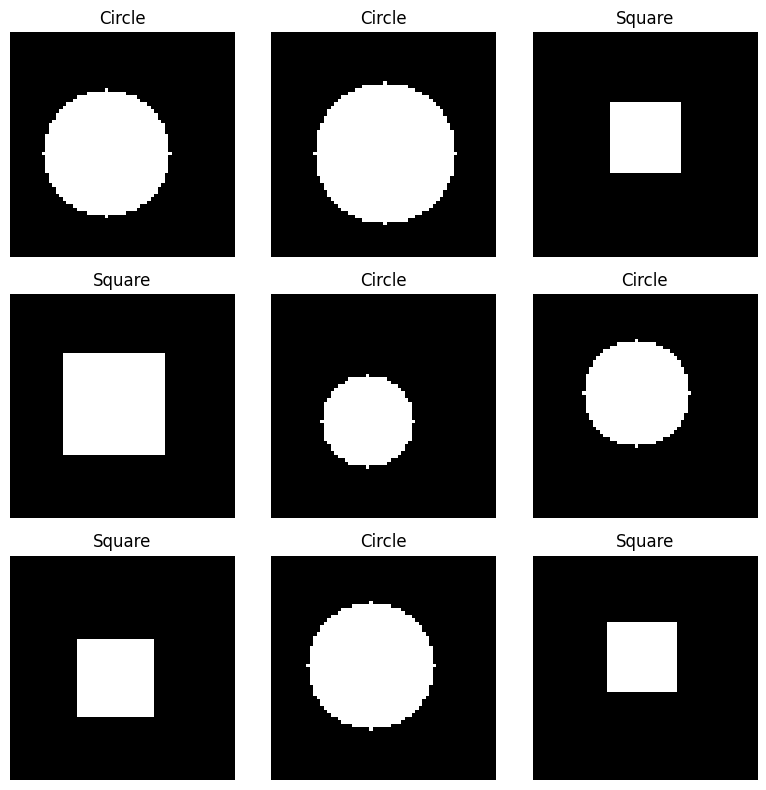

✅ Image saved successfully as generated_shapes.png


In [9]:
plt.figure(figsize=(8, 8))

random_indices = random.sample(range(len(images)), 9)

for i, idx in enumerate(random_indices):

    plt.subplot(3, 3, i + 1)

    plt.imshow(images[idx][0], cmap="gray")

    title = "Circle" if labels[idx] == 0 else "Square"

    plt.title(title)

    plt.axis("off")

plt.tight_layout()

# Save the figure
plt.savefig("generated_shapes.png", dpi=300, bbox_inches="tight")

plt.show()

print("✅ Image saved successfully as generated_shapes.png")

## Step 7: Build the Generator Network

The Generator is responsible for creating synthetic images from random noise and class labels.

Unlike a traditional GAN, the Conditional GAN (CGAN) receives both:

- Random noise vector
- Class label (Circle or Square)

These inputs are combined to generate an image corresponding to the given label.

In [11]:
class Generator(nn.Module):

    def __init__(self):

        super(Generator, self).__init__()

        # Label Embedding
        self.label_embedding = nn.Embedding(NUM_CLASSES, 10)

        # Generator Network
        self.model = nn.Sequential(

            nn.Linear(100 + 10, 256),
            nn.ReLU(True),

            nn.Linear(256, 512),
            nn.ReLU(True),

            nn.Linear(512, 1024),
            nn.ReLU(True),

            nn.Linear(1024, IMG_SIZE * IMG_SIZE),
            nn.Tanh()
        )

    def forward(self, noise, labels):

        embedded_labels = self.label_embedding(labels)

        generator_input = torch.cat((noise, embedded_labels), dim=1)

        output = self.model(generator_input)

        output = output.view(-1, 1, IMG_SIZE, IMG_SIZE)

        return output

### Test the Generator

Before training the CGAN, we verify that the Generator can successfully create an output image tensor using random noise and class labels.

In [12]:
generator = Generator().to(device)

noise = torch.randn(4, 100).to(device)

labels_test = torch.tensor([0, 1, 0, 1]).to(device)

generated_images = generator(noise, labels_test)

print("Generator Created Successfully!")

print("Generated Image Shape:")

print(generated_images.shape)

Generator Created Successfully!
Generated Image Shape:
torch.Size([4, 1, 64, 64])


## Step 8: Build the Discriminator Network

The Discriminator learns to distinguish between real and fake images.

Unlike a traditional GAN, the Conditional GAN (CGAN) also receives the class label along with the image.

Its objective is to determine whether the generated image matches the given label and whether it is real or fake.

In [13]:
class Discriminator(nn.Module):

    def __init__(self):

        super(Discriminator, self).__init__()

        # Label Embedding
        self.label_embedding = nn.Embedding(NUM_CLASSES, IMG_SIZE * IMG_SIZE)

        # Discriminator Network
        self.model = nn.Sequential(

            nn.Linear(IMG_SIZE * IMG_SIZE * 2, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, image, labels):

        image = image.view(image.size(0), -1)

        embedded_labels = self.label_embedding(labels)

        discriminator_input = torch.cat(
            (image, embedded_labels), dim=1
        )

        output = self.model(discriminator_input)

        return output

### Test the Discriminator

Before training, we verify that the Discriminator accepts both an image and its corresponding class label and produces a probability indicating whether the image is real or fake.

In [14]:
discriminator = Discriminator().to(device)

prediction = discriminator(
    generated_images,
    labels_test
)

print("Discriminator Created Successfully!")

print("Prediction Shape:")

print(prediction.shape)

print("\nSample Predictions:")

print(prediction)

Discriminator Created Successfully!
Prediction Shape:
torch.Size([4, 1])

Sample Predictions:
tensor([[0.5170],
        [0.5189],
        [0.5170],
        [0.5183]], grad_fn=<SigmoidBackward0>)


## Step 9: Define Loss Function and Optimizers

To train the Conditional GAN, we define:

- Binary Cross Entropy (BCE) Loss
- Adam Optimizer for the Generator
- Adam Optimizer for the Discriminator

These components help both networks learn during adversarial training.

In [15]:
# Binary Cross Entropy Loss
criterion = nn.BCELoss()

# Optimizers
optimizer_G = optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

print("Loss Function and Optimizers Initialized Successfully!")

Loss Function and Optimizers Initialized Successfully!


## Step 10: Convert Dataset into PyTorch DataLoader

The generated images and labels are converted into PyTorch tensors and loaded using a DataLoader. This allows efficient batch-wise training of the Conditional GAN.

In [16]:
from torch.utils.data import TensorDataset, DataLoader

# Convert NumPy arrays to tensors
images_tensor = torch.tensor(images, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.long)

# Create dataset
dataset = TensorDataset(images_tensor, labels_tensor)

# Create DataLoader
dataloader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

print("Dataset loaded into DataLoader successfully!")
print("Number of batches:", len(dataloader))

Dataset loaded into DataLoader successfully!
Number of batches: 32


## Step 11: Train the Conditional GAN

During training:

- The Discriminator learns to distinguish between real and generated images.
- The Generator learns to create images that fool the Discriminator.
- Both networks improve together through adversarial learning.

The Generator receives both random noise and the class label, enabling it to generate images corresponding to the specified category.

In [17]:
# Training Parameters

EPOCHS = 20
LATENT_DIM = 100

print("Starting Training...\n")

for epoch in range(EPOCHS):

    for real_images, labels_batch in dataloader:

        batch_size = real_images.size(0)

        real_images = real_images.to(device)
        labels_batch = labels_batch.to(device)

        real = torch.ones(batch_size, 1).to(device)
        fake = torch.zeros(batch_size, 1).to(device)

        # ---------------------
        # Train Discriminator
        # ---------------------

        optimizer_D.zero_grad()

        real_output = discriminator(real_images, labels_batch)

        d_real_loss = criterion(real_output, real)

        noise = torch.randn(batch_size, LATENT_DIM).to(device)

        fake_images = generator(noise, labels_batch)

        fake_output = discriminator(fake_images.detach(), labels_batch)

        d_fake_loss = criterion(fake_output, fake)

        d_loss = d_real_loss + d_fake_loss

        d_loss.backward()

        optimizer_D.step()

        # ---------------------
        # Train Generator
        # ---------------------

        optimizer_G.zero_grad()

        noise = torch.randn(batch_size, LATENT_DIM).to(device)

        generated_images = generator(noise, labels_batch)

        predictions = discriminator(generated_images, labels_batch)

        g_loss = criterion(predictions, real)

        g_loss.backward()

        optimizer_G.step()

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"D Loss: {d_loss.item():.4f} | "
        f"G Loss: {g_loss.item():.4f}"
    )

print("\nTraining Completed Successfully!")

Starting Training...

Epoch [1/20] | D Loss: 1.4606 | G Loss: 0.5678
Epoch [2/20] | D Loss: 1.6853 | G Loss: 0.7037
Epoch [3/20] | D Loss: 1.3802 | G Loss: 1.0085
Epoch [4/20] | D Loss: 1.1989 | G Loss: 1.1013
Epoch [5/20] | D Loss: 1.0977 | G Loss: 1.1452
Epoch [6/20] | D Loss: 1.3698 | G Loss: 1.9708
Epoch [7/20] | D Loss: 1.4175 | G Loss: 1.0486
Epoch [8/20] | D Loss: 1.2785 | G Loss: 1.0061
Epoch [9/20] | D Loss: 1.2596 | G Loss: 0.3980
Epoch [10/20] | D Loss: 1.2228 | G Loss: 1.1461
Epoch [11/20] | D Loss: 1.1734 | G Loss: 0.8146
Epoch [12/20] | D Loss: 0.9565 | G Loss: 1.1243
Epoch [13/20] | D Loss: 1.1223 | G Loss: 1.5194
Epoch [14/20] | D Loss: 1.4627 | G Loss: 1.4317
Epoch [15/20] | D Loss: 1.8099 | G Loss: 0.7542
Epoch [16/20] | D Loss: 1.2318 | G Loss: 0.9226
Epoch [17/20] | D Loss: 1.0593 | G Loss: 1.5832
Epoch [18/20] | D Loss: 0.9896 | G Loss: 1.7524
Epoch [19/20] | D Loss: 1.0554 | G Loss: 1.1343
Epoch [20/20] | D Loss: 0.9296 | G Loss: 1.7186

Training Completed Success

## Step 12: Generate Images Using the Trained Generator

After training, the Generator can create images based on the provided class labels.

In this step, we generate:

- Circle (Label 0)
- Square (Label 1)

using random noise vectors and visualize the generated results.

In [18]:
# Set generator to evaluation mode
generator.eval()

# Create random noise
noise = torch.randn(8, LATENT_DIM).to(device)

# Labels:
# First 4 -> Circle
# Last 4 -> Square
test_labels = torch.tensor(
    [0, 0, 0, 0, 1, 1, 1, 1],
    dtype=torch.long
).to(device)

# Generate images
with torch.no_grad():
    generated = generator(noise, test_labels)

generated = generated.cpu()

## Step 13: Display Generated Images

The generated images are visualized to verify that the Conditional GAN has learned to produce different shapes based on the provided labels.

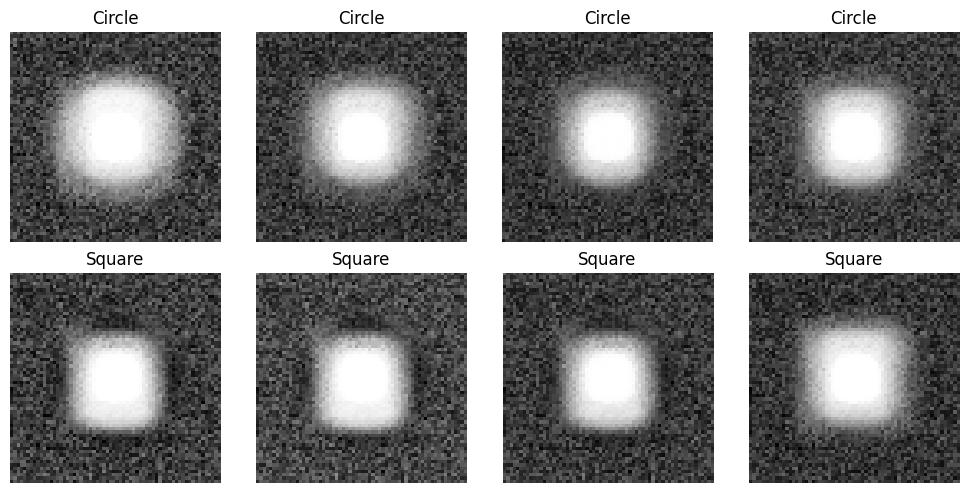

✅ Generated images saved as generated_cgan_shapes.png


In [19]:
plt.figure(figsize=(10,5))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(generated[i][0], cmap="gray")

    if test_labels[i] == 0:
        plt.title("Circle")
    else:
        plt.title("Square")

    plt.axis("off")

plt.tight_layout()

# Save generated image
plt.savefig("generated_cgan_shapes.png", dpi=300, bbox_inches="tight")

plt.show()

print("✅ Generated images saved as generated_cgan_shapes.png")

# Conclusion

In this task, a Conditional Generative Adversarial Network (CGAN) was implemented using PyTorch.

The project demonstrated:

- Creation of a synthetic dataset containing circles and squares
- Construction of the Generator and Discriminator networks
- Use of conditional labels during image generation
- Training of the CGAN using adversarial learning
- Generation of images conditioned on class labels

This task introduced the concept of conditional image generation, where additional information (labels) guides the Generator to produce category-specific images.